# Clasificación de Residuos — Modelo A4: CNN Large

---

## Contexto del Experimento

Este notebook forma parte de una **serie de experimentos de complejidad creciente** para estudiar el impacto de la arquitectura en el rendimiento de redes neuronales convolucionales aplicadas a la clasificación de residuos.

### Estrategia Experimental

- **Punto de partida**: Modelo baseline A1 (red simple del notebook 2.3)
- **Enfoque**: Incrementos progresivos en la capacidad del modelo
- **Observables**: Evolución del error de entrenamiento y validación

Cada modelo se implementa en un archivo independiente dentro de la carpeta `models/` del proyecto.

---

## Arquitectura del Modelo A4

### Descripción

**CNN Large** añade un **tercer bloque convolucional (128 filtros)** e introduce **BatchNormalization** en todos los bloques para estabilizar el entrenamiento al aumentar la profundidad. No se añade aún capa densa ni Dropout — eso llega en A5.

### Modificaciones Respecto a A3

| Componente | A3 (Anterior) | A4 (Este modelo) |
|------------|---------------|------------------|
| **Capas Conv** | 2 capas (32, 64) | **3 capas** (32, 64, 128) |
| **BatchNormalization** | No | **Sí** (en todos los bloques) |
| **MaxPooling** | 1× (tras conv1) | **3×** (tras cada bloque) |
| **Cabeza densa** | GAP → softmax | GAP → softmax (igual) |
| **Parámetros** | ~20K | **~95K** |

**Hipótesis**: El tercer bloque permite capturar características jerárquicas más complejas (bordes → texturas → patrones). La BatchNormalization estabiliza el entrenamiento al aumentar la profundidad y acelera la convergencia.

---
## Resumen resultado final rendimiento en el conjunto de test

| Modelo | Parámetros | Accuracy | Precision | Recall | F1-Score |
|--------|----------:|--------:|----------:|-------:|--------:|
| A1 (SimpleCNN) | 210 | 0.4921 | 0.4257 | 0.4326 | 0.4150 |
| A2 (CNN Small) | 1,094 | 0.61 | 0.66 | 0.56 | 0.57 |
| A3 (CNN Medium) | 19,782 | 0.7263 | 0.7114 | 0.6884 | 0.6973 |
| **A4 (CNN Large)** | **94,918** | **0.7816** | **0.7643** | **0.7741** | **0.7578** |
## Implementación

A continuación se entrena y evalúa el modelo A4 usando el pipeline estándar del proyecto.

In [1]:
# ========================================
# 1. IMPORTS Y CONFIGURACION
# ========================================

import os
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import keras

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score
)

# Agregar ruta del proyecto al path (carpeta padre de notebooks)
sys.path.insert(0, '..')

# Importar funciones de utilidad
from src.utils import initialize_project

2026-03-13 12:39:33.414661: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-13 12:39:33.414845: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-13 12:39:33.440798: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-13 12:39:34.067337: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off,

---
## 1. Carga de datos

In [2]:
# ========================================
# 2. CARGA DE DATOS Y CONFIGURACION
# ========================================

X_train, y_train, X_val, y_val, X_test, y_test, class_names = initialize_project()

Ejecutando en local

Cargando datos desde: /home/anuega/archivos/notebooks/../data/processed/trashnet_224x224.npz
  X.shape: (2527, 224, 224, 3)
  y.shape: (2527,)
  Clases: cardboard, glass, metal, paper, plastic, trash

División estratificada (seed=44):
  Train: 1768 imágenes (70%)
  Val:   379 imágenes (15%)
  Test:  380 imágenes (15%)


In [3]:
# ========================================
# 2.1 DATASET + AUMENTACION
# ========================================

SEED = 44
BATCH_SIZE = 64
NUM_CLASSES = len(class_names)

augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.05, 0.05),
], name='augmentation')

def make_dataset(X, y, training=False):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if training:
        ds = ds.shuffle(len(X), seed=SEED)
        ds = ds.map(
            lambda x, y: (augmentation(x, training=True), y),
            num_parallel_calls=tf.data.AUTOTUNE
        )
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

ds_train = make_dataset(X_train, y_train, training=True)
ds_val   = make_dataset(X_val,   y_val,   training=False)

print('Datasets con augmentacion listos')

E0000 00:00:1773401979.069517 2218426 cuda_executor.cc:1309] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1773401979.075391 2218426 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Datasets con augmentacion listos


---
## 2. Definición del modelo

In [4]:
# ========================================
# 3. DEFINICION DEL MODELO A4
# ========================================

from models.A4_cnn_large import build_cnn_large as build_model

model = build_model(input_shape=(224, 224, 3), num_classes=6)
model.summary()

Model: "A4_CNN_Large"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,918 (370.77 KB)

 Trainable params: 94,470 (369.02 KB)

 Non-trainable params: 448 (1.75 KB)

---
## 3. Entrenamiento

In [7]:
# ========================================
# 4. CONFIGURACION Y ENTRENAMIENTO
# ========================================

MODEL_NAME = 'A4_cnn_large'

# ── Callbacks ────────────────────────────────────────────────────
cb_early_stop = callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=100,
    restore_best_weights=True,
    mode='max',
    verbose=1
)

cb_checkpoint = callbacks.ModelCheckpoint(
    filepath=f'best_{MODEL_NAME}_phase1.keras',
    monitor='val_accuracy',
    mode='max',
    save_best_only=True,
    verbose=0
)

# ── Scheduler CosineDecay ────────────────────────────────────────
EPOCHS = 100
steps_per_epoch = max(1, len(X_train) // BATCH_SIZE)
total_steps = steps_per_epoch * EPOCHS

lr_scheduler = keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-3,
    decay_steps=total_steps,
    alpha=1e-2

)

model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=lr_scheduler,
        weight_decay=1e-4
    ),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# ── Entrenamiento ────────────────────────────────────────────────────────────
history_p1 = model.fit(
    ds_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    callbacks=[cb_early_stop, cb_checkpoint],
    verbose=1
)

Epoch 1/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 21s 739ms/step - accuracy: 0.5294 - loss: 1.2257 - val_accuracy: 0.1900 - val_loss: 1.9265
Epoch 2/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 20s 727ms/step - accuracy: 0.6092 - loss: 1.0704 - val_accuracy: 0.2111 - val_loss: 1.9104
Epoch 3/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 20s 729ms/step - accuracy: 0.6126 - loss: 1.0488 - val_accuracy: 0.2348 - val_loss: 1.9281
Epoch 4/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 21s 738ms/step - accuracy: 0.6346 - loss: 0.9990 - val_accuracy: 0.2322 - val_loss: 1.8799
Epoch 5/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 21s 733ms/step - accuracy: 0.6538 - loss: 0.9552 - val_accuracy: 0.2955 - val_loss: 2.0419
Epoch 6/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 21s 732ms/step - accuracy: 0.6510 - loss: 0.9432 - val_accuracy: 0.2348 - val_loss: 2.4950
Epoch 7/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 21s 735ms/step - accuracy: 0.6702 - loss: 0.9073 - val_accuracy: 0.3720 - val_loss: 1.9365
Epoch 8/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 21s 736ms/step - accuracy: 0.6742 - loss: 0.9034 - 

---
## 4. Curvas de entrenamiento

In [8]:
def plot_training(history, title='', phase=1):
    loss     = history.history['loss']
    val_loss = history.history['val_loss']
    acc      = history.history['accuracy']
    val_acc  = history.history['val_accuracy']
    epochs   = range(1, len(loss) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(18, 10))
    fig.suptitle(f'{title} — Fase {phase}', fontsize=14, fontweight='bold')

    # ── Loss ─────────────────────────────────────────────────────────────────
    axes[0].plot(epochs, loss,     label='Train')
    axes[0].plot(epochs, val_loss, label='Validación')
    axes[0].set_title('Loss — Completa')
    axes[0].set_xlabel('Época'); axes[0].set_ylabel('Loss')
    axes[0].legend()

    # ── Accuracy ─────────────────────────────────────────────────────────────
    axes[1].plot(epochs, acc,     label='Train')
    axes[1].plot(epochs, val_acc, label='Validación')
    axes[1].set_title('Accuracy — Completa')
    axes[1].set_xlabel('Época'); axes[1].set_ylabel('Accuracy')
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(f'curvas_{MODEL_NAME}_fase{phase}.png', dpi=150)
    plt.show()

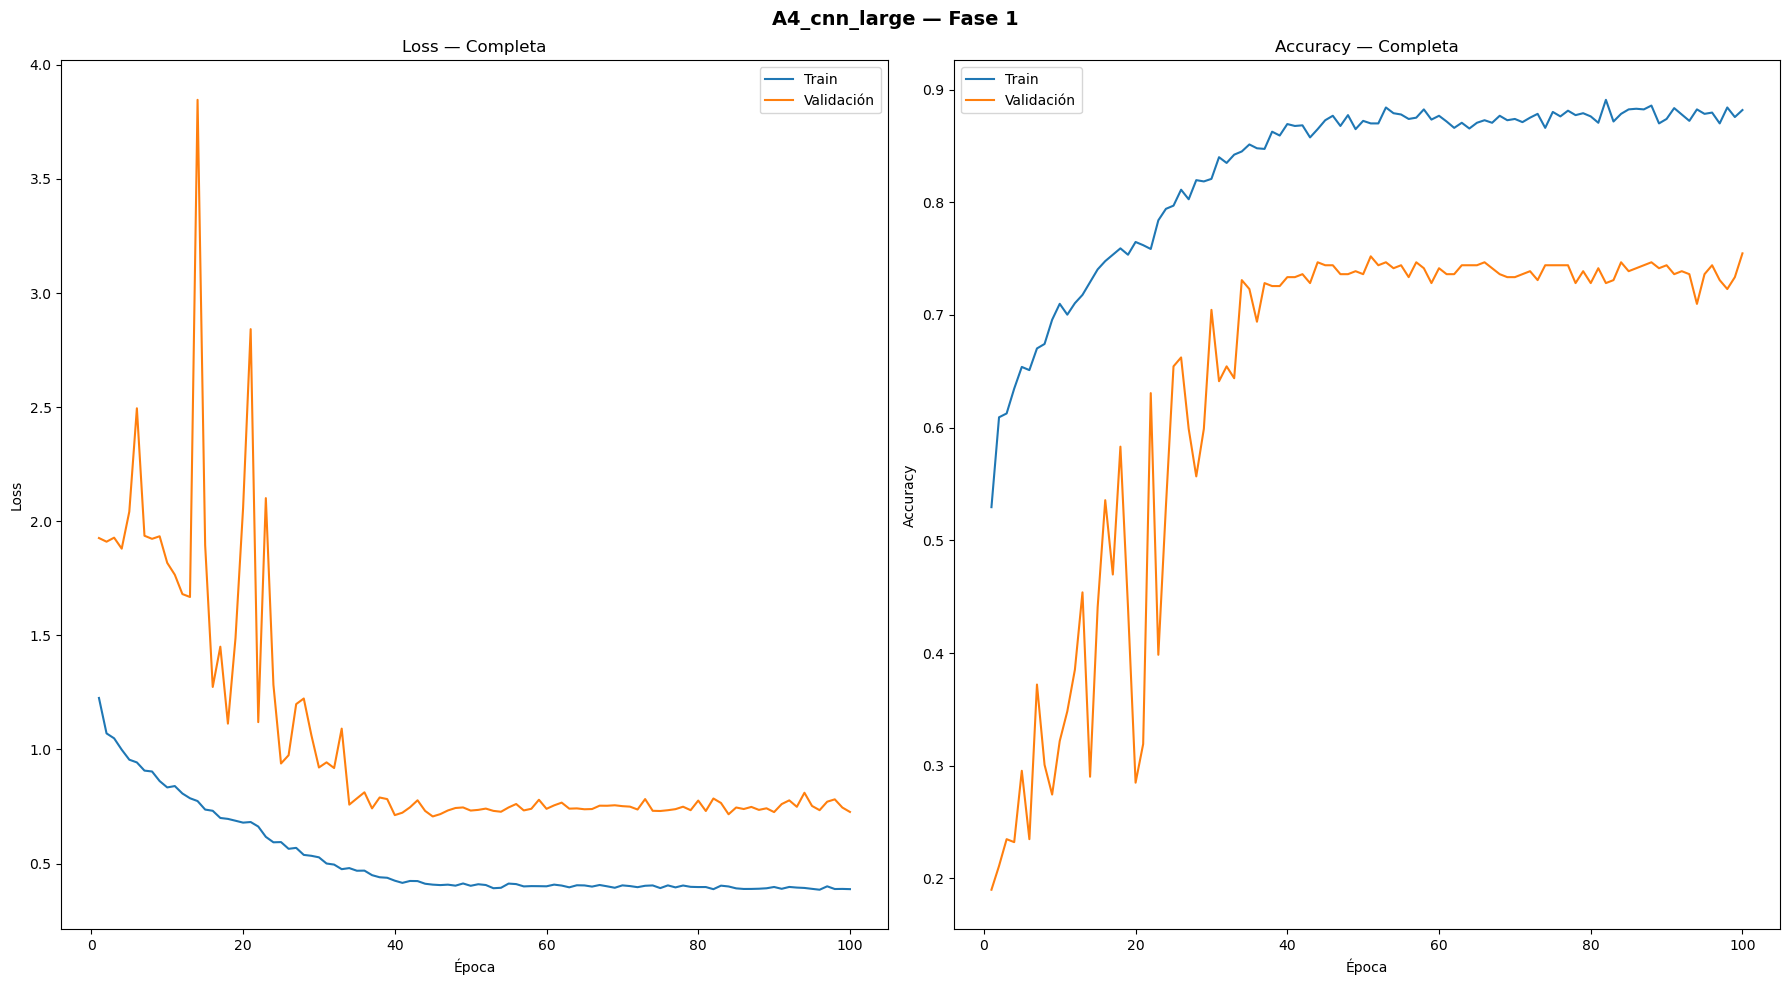

In [9]:
plot_training(history_p1, title=MODEL_NAME, phase=1)

---
## 5. Evaluación

Se selecciona el mejor modelo en función de la validación.

In [10]:
def evaluate_split(model, X, y, split_name):
    """Calcula y muestra Accuracy, Precision, Recall y F1-macro."""
    y_pred = np.argmax(model.predict(X, verbose=0), axis=1)
    acc  = accuracy_score(y, y_pred)
    prec = precision_score(y, y_pred, average='macro', zero_division=0)
    rec  = recall_score(y, y_pred, average='macro', zero_division=0)
    f1   = f1_score(y, y_pred, average='macro', zero_division=0)
    print(f'[{split_name:>5}]  Acc={acc:.4f}  Prec={prec:.4f}  '
          f'Rec={rec:.4f}  F1={f1:.4f}')
    return {'split': split_name, 'acc': acc,
            'prec': prec, 'rec': rec, 'f1': f1, 'y_pred': y_pred}


print('=' * 60)
print(f'Modelo: {MODEL_NAME}')
print('=' * 60)
res_train = evaluate_split(model, X_train, y_train, 'Train')
res_val   = evaluate_split(model, X_val,   y_val,   'Val')
res_test  = evaluate_split(model, X_test,  y_test,  'Test')
print('=' * 60)

Modelo: A4_cnn_large
[Train]  Acc=0.8343  Prec=0.8146  Rec=0.8346  F1=0.8127
[  Val]  Acc=0.7546  Prec=0.7480  Rec=0.7558  F1=0.7301
[ Test]  Acc=0.7816  Prec=0.7643  Rec=0.7741  F1=0.7578


In [11]:
# ── Número de parámetros  ──────────────────────────
total_params     = model.count_params()
trainable_params = sum([tf.size(w).numpy() for w in model.trainable_weights])

print(f'Parámetros totales    : {total_params:,}')
print(f'Parámetros entrenables: {trainable_params:,}')

Parámetros totales    : 94,918
Parámetros entrenables: 94,470


---
## 6. Métricas por partición

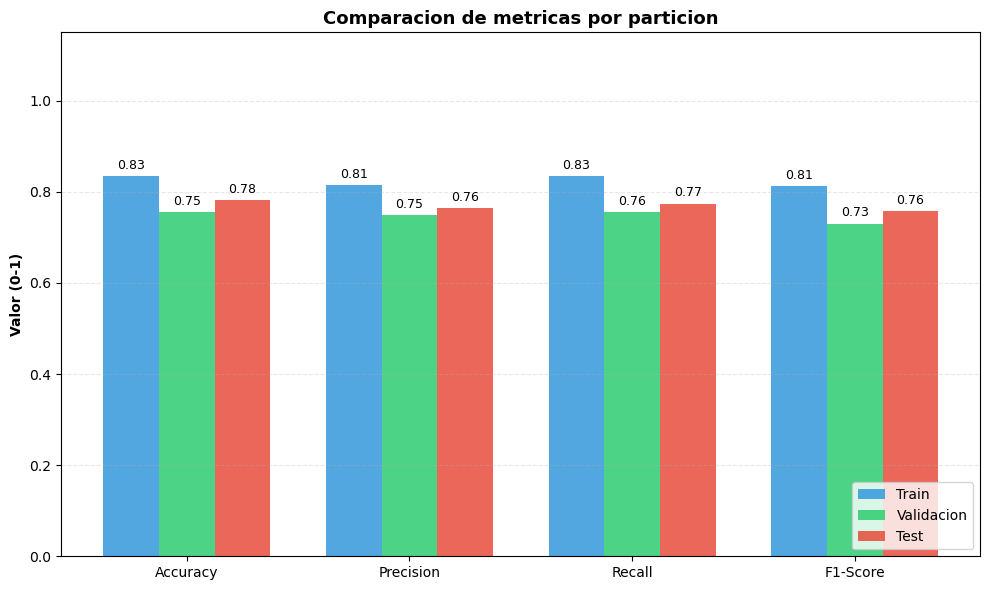

In [15]:
# ========================================
# GRAFICO DE BARRAS DE METRICAS (TRAIN / VAL / TEST)
# ========================================
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(metrics_names))
width = 0.25

results_train = [res_train['acc'], res_train['prec'], res_train['rec'], res_train['f1']]
results_val   = [res_val['acc'],   res_val['prec'],   res_val['rec'],   res_val['f1']]
results_test  = [res_test['acc'],  res_test['prec'],  res_test['rec'],  res_test['f1']]

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width, results_train, width, label='Train',      color='#3498db', alpha=0.85)
rects2 = ax.bar(x,         results_val,   width, label='Validacion', color='#2ecc71', alpha=0.85)
rects3 = ax.bar(x + width, results_test,  width, label='Test',       color='#e74c3c', alpha=0.85)

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(
            f'{height:.2f}',
            xy=(rect.get_x() + rect.get_width() / 2, height),
            xytext=(0, 3),
            textcoords='offset points',
            ha='center', va='bottom', fontsize=9
        )

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

ax.set_ylabel('Valor (0-1)', fontweight='bold')
ax.set_title('Comparacion de metricas por particion', fontweight='bold', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(metrics_names)
ax.set_ylim(0, 1.15)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.legend(loc='lower right')

plt.tight_layout()
plt.show()

---
## 7. Matrices de confusión

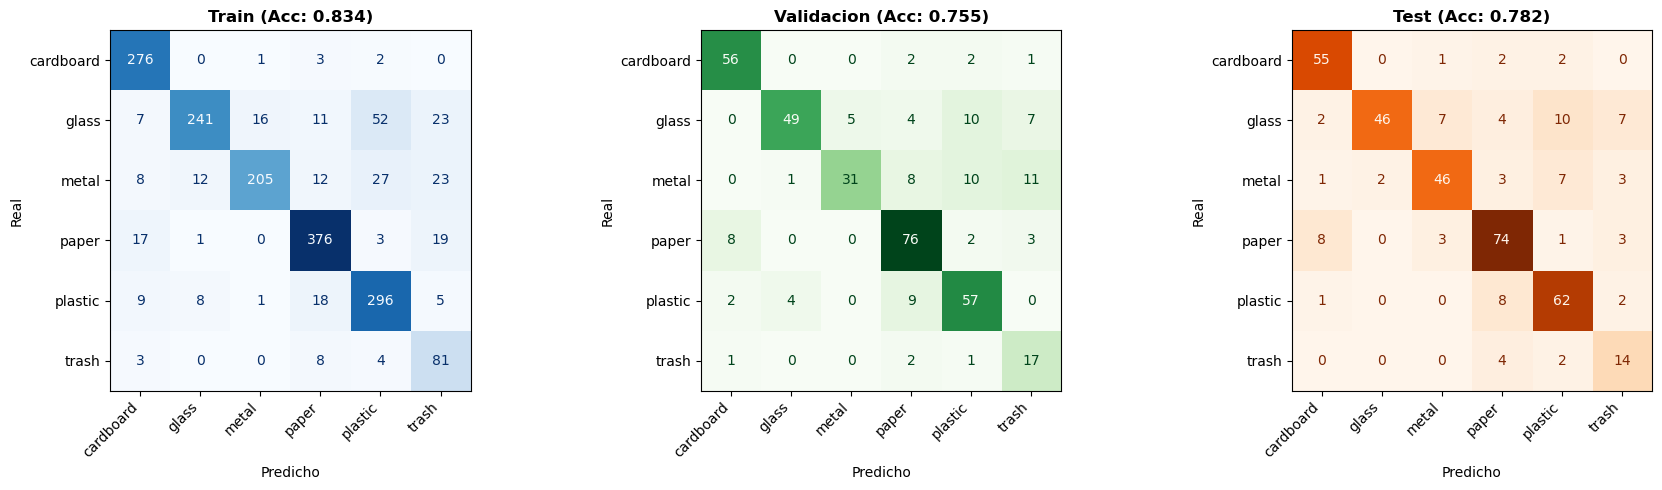

              precision    recall  f1-score   support

   cardboard       0.82      0.92      0.87        60
       glass       0.96      0.61      0.74        76
       metal       0.81      0.74      0.77        62
       paper       0.78      0.83      0.80        89
     plastic       0.74      0.85      0.79        73
       trash       0.48      0.70      0.57        20

    accuracy                           0.78       380
   macro avg       0.76      0.77      0.76       380
weighted avg       0.80      0.78      0.78       380



In [13]:
# ========================================
# MATRICES DE CONFUSION PARA TRAIN / VAL / TEST
# ========================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

y_pred_train = res_train['y_pred']
y_pred_val   = res_val['y_pred']
y_pred_test  = res_test['y_pred']

# Train
cm_train = confusion_matrix(y_train, y_pred_train)
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=class_names)
disp_train.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(f"Train (Acc: {res_train['acc']:.3f})", fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicho', fontsize=10)
axes[0].set_ylabel('Real', fontsize=10)
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45, ha='right')

# Validacion
cm_val = confusion_matrix(y_val, y_pred_val)
disp_val = ConfusionMatrixDisplay(confusion_matrix=cm_val, display_labels=class_names)
disp_val.plot(ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title(f"Validacion (Acc: {res_val['acc']:.3f})", fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicho', fontsize=10)
axes[1].set_ylabel('Real', fontsize=10)
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha='right')

# Test
cm_test = confusion_matrix(y_test, y_pred_test)
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=class_names)
disp_test.plot(ax=axes[2], cmap='Oranges', colorbar=False)
axes[2].set_title(f"Test (Acc: {res_test['acc']:.3f})", fontsize=12, fontweight='bold')
axes[2].set_xlabel('Predicho', fontsize=10)
axes[2].set_ylabel('Real', fontsize=10)
plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig(f'confusion_{MODEL_NAME}_all_splits.png', dpi=150)
plt.show()

print(classification_report(
    y_test,
    y_pred_test,
    target_names=class_names
))

---
## 8. Conclusiones — Modelo A4 (CNN Large)

El modelo **A4_cnn_large** consolida la mejora respecto a arquitecturas más simples gracias al tercer bloque convolucional y a `BatchNormalization`, logrando un buen equilibrio entre capacidad y generalización.

Al observar la gráfica de pérdidas, se ve que la **pérdida de validación fluctúa bastante al inicio**. Esto es esperable porque se está usando **aumentación de datos** de forma activa para **regularizar más** el entrenamiento; sin esta regularización, el modelo tendía a **sobreajustar** con mayor rapidez. Después de las primeras épocas, la validación se estabiliza y mantiene una brecha razonable frente a entrenamiento.

### Comparación de modelos: A1 vs A2 vs A3 vs A4

| Modelo | Partición | Accuracy | Precision | Recall | F1-Score |
|--------|-----------|--------:|----------:|-------:|--------:|
| A1 (SimpleCNN) | Train | 0.4717 | 0.4138 | 0.4100 | 0.3937 |
| A1 (SimpleCNN) | Val | 0.4802 | 0.4406 | 0.4138 | 0.4030 |
| A1 (SimpleCNN) | Test | 0.4921 | 0.4257 | 0.4326 | 0.4150 |
| A2 (CNN Small) | Train | 0.64 | 0.63 | 0.57 | 0.57 |
| A2 (CNN Small) | Val | 0.62 | 0.65 | 0.55 | 0.56 |
| A2 (CNN Small) | Test | 0.61 | 0.66 | 0.56 | 0.57 |
| A3 (CNN Medium) | Train | 0.8360 | 0.8268 | 0.8121 | 0.8184 |
| A3 (CNN Medium) | Val | 0.7414 | 0.7149 | 0.6954 | 0.7010 |
| A3 (CNN Medium) | Test | 0.7263 | 0.7114 | 0.6884 | 0.6973 |
| **A4 (CNN Large)** | **Train** | **0.8343** | **0.8146** | **0.8346** | **0.8127** |
| **A4 (CNN Large)** | **Val** | **0.7546** | **0.7480** | **0.7558** | **0.7301** |
| **A4 (CNN Large)** | **Test** | **0.7816** | **0.7643** | **0.7741** | **0.7578** |

### Comparación de rendimiento en el conjunto de Test

| Modelo | Parámetros | Accuracy | Precision | Recall | F1-Score |
|--------|----------:|--------:|----------:|-------:|--------:|
| A1 (SimpleCNN) | 210 | 0.4921 | 0.4257 | 0.4326 | 0.4150 |
| A2 (CNN Small) | 1,094 | 0.61 | 0.66 | 0.56 | 0.57 |
| A3 (CNN Medium) | 19,782 | 0.7263 | 0.7114 | 0.6884 | 0.6973 |
| **A4 (CNN Large)** | **94,918** | **0.7816** | **0.7643** | **0.7741** | **0.7578** |